In [79]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [80]:
df = pd.read_csv('titanic.csv')
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [48]:
X = df[['Pclass', 'Age', 'Fare']].copy()
y = df['Survived']

In [52]:
X['Age'] = X['Age'].fillna(X['Age'].mean())
X['Fare'] = X['Fare'].fillna(X['Fare'].mean())

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [72]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [73]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [74]:
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.7354260089686099


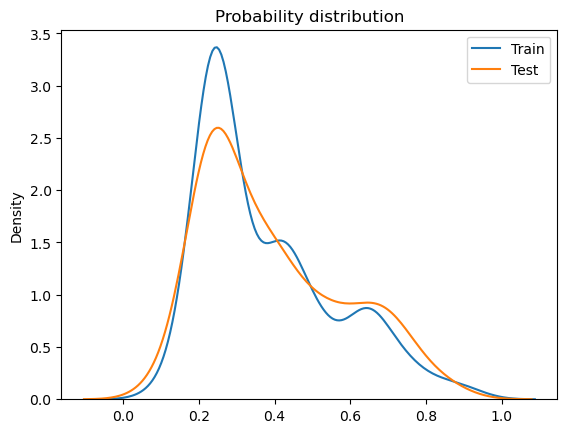

In [81]:
y_train_prob = model.predict_proba(X_train)[:,1]
y_test_prob = model.predict_proba(X_test)[:,1]

sns.kdeplot(y_train_prob, label='Train')
sns.kdeplot(y_test_prob, label='Test')

plt.legend()
plt.title("Probability distribution")
plt.show()